In [18]:
import urllib
import requests

urls = "https://www.who.int"
req = urllib.request.Request(
    urls,
    headers={"User-Agent": "Magic Browser"}
)
con = urllib.request.urlopen(req)
html = con.read()
print(type(html))


<class 'bytes'>


In [19]:
#BeautifulSoupでHTMLを読む
import urllib.request
from bs4 import BeautifulSoup

# URL = input("please provide the URL: ")
URL = "https://www.who.int"

request = urllib.request.Request(
    URL,
    headers={"User-Agent": "Magic Browser"}
)
con = urllib.request.urlopen(request)
html = con.read()

# soup = BeautifulSoup(html, "lxml")
soup = BeautifulSoup(html, "html.parser")

# print(soup.prettify())

# Get the page title
print("Title:", soup.title.string)

# Extract all headings
# for heading in soup.find_all(['h1', 'h2', 'h3']):
#     print(heading.get_text(strip=True))
#     print("--------------------")

# Extract all links
# for link in soup.find_all('a', href=True):
#     print(link['href'])


Title: 
	World Health Organization (WHO)



In [30]:
for link in soup.find_all('a', href=True):
    text = link.get_text(strip=True)
    if text:  # 空文字を除外（WHOサイトは多い）
        print(text)

Skip to main content
Global
Regions
Africa
Americas
South-East Asia
Europe
Eastern Mediterranean
Western Pacific
Home
Health Topics
All topics
A
B
C
D
E
F
G
H
I
J
K
L
M
N
O
P
Q
R
S
T
U
V
W
X
Y
Z
Resources
Fact sheets
Facts in pictures
Multimedia
Podcasts
Publications
Questions and answers
Tools and toolkits
Popular
Dengue
Endometriosis
Excessive heat
Herpes
Mental disorders
Mpox
Countries
All countries
A
B
C
D
E
F
G
H
I
J
K
L
M
N
O
P
Q
R
S
T
U
V
W
X
Y
Z
Regions
Africa
Americas
Europe
Eastern Mediterranean
South-East Asia
Western Pacific
WHO in countries
Data by country
Country presence
Country cooperation strategies
Country office profiles
Strengthening country offices
Newsroom
All news
News releases
Statements
Campaigns
Events
Feature stories
Press conferences
Speeches
Commentaries
Photo library
Headlines
Emergencies
Focus on
Cholera
Coronavirus disease (COVID-19)
Greater Horn of Africa
Israel and occupied Palestinian territory
Mpox
Sudan
Ukraine
Latest
Disease Outbreak News
Situation

In [31]:
unique_tags_set = set(tag_names)

print("Unique HTML tag names:")
for tag in sorted(unique_tags_set):
    print(tag)

Unique HTML tag names:
a
article
body
br
div
footer
h1
h2
h3
head
header
html
i
iframe
img
input
label
li
link
meta
nav
noscript
option
p
path
script
section
select
span
strong
style
svg
title
ul


In [32]:
#タグ集計（Top5）
from collections import Counter

# Normalize names (lowercase, drop XML namespace prefixes like 'svg:use' -> 'use')
tag_names = [t.name.lower().split(":")[-1] for t in soup.find_all(True)]

total_tags = len(tag_names)
unique_tags_set = set(tag_names)
unique_tags_count = len(unique_tags_set)

top5 = Counter(tag_names).most_common(5)

print(f"Total tags: {total_tags}")
print(f"Unique tags: {unique_tags_count}")
print("Top 5 tags (tag: count):")
for name, cnt in top5:
    print(f"{name}: {cnt}")
    
print("Unique HTML tag names:")
for tag in sorted(unique_tags_set):
    print(tag)


Total tags: 1065
Unique tags: 34
Top 5 tags (tag: count):
div: 326
a: 239
li: 194
ul: 52
script: 40
Unique HTML tag names:
a
article
body
br
div
footer
h1
h2
h3
head
header
html
i
iframe
img
input
label
li
link
meta
nav
noscript
option
p
path
script
section
select
span
strong
style
svg
title
ul


In [33]:
top5 = Counter(tag_names).most_common(5)

print("Top 5 tags (tag: count):")
for name, cnt in top5:
    print(f"{name}: {cnt}")

Top 5 tags (tag: count):
div: 326
a: 239
li: 194
ul: 52
script: 40


In [34]:
#タグ一覧テーブル
from collections import Counter

tag_names = [t.name.lower().split(":")[-1] for t in soup.find_all(True)]
counts = Counter(tag_names)

print(f"{'Tag':<18} {'Count':>7}")
print("-" * 26)
for tag, cnt in sorted(counts.items(), key=lambda x: (-x[1], x[0])):
    print(f"{tag:<18} {cnt:>7}")



Tag                  Count
--------------------------
div                    326
a                      239
li                     194
ul                      52
script                  40
h3                      25
img                     25
span                    24
input                   18
link                    18
article                 14
i                       11
meta                    11
p                       11
h2                       9
nav                      9
option                   7
path                     7
svg                      7
style                    4
body                     1
br                       1
footer                   1
h1                       1
head                     1
header                   1
html                     1
iframe                   1
label                    1
noscript                 1
section                  1
select                   1
strong                   1
title                    1


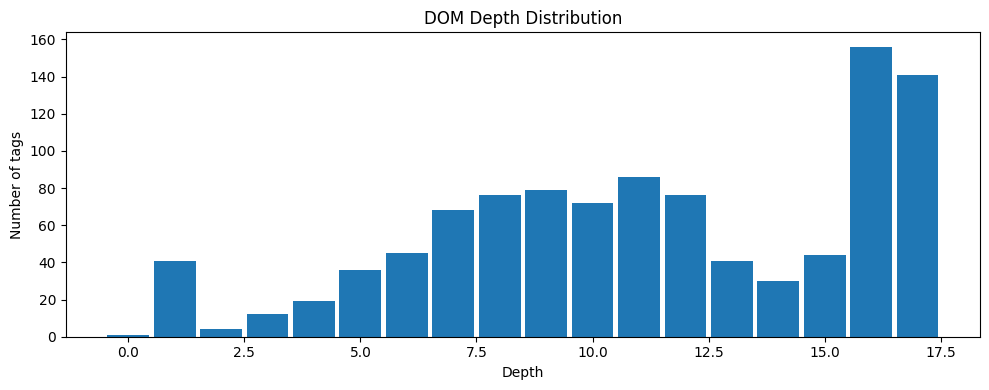

In [35]:
#DOM 深さ分布（ヒストグラム）
from bs4 import Tag
import matplotlib.pyplot as plt
from collections import deque

def tag_depths(root):
    depths = []
    q = deque([(root, 0)])
    while q:
        node, d = q.popleft()
        if isinstance(node, Tag):
            depths.append(d)
            for c in node.children:
                if isinstance(c, Tag):
                    q.append((c, d + 1))
    return depths

root = soup.body or soup
depths = tag_depths(root)

plt.figure(figsize=(10, 4))
plt.hist(depths, bins=range(0, max(depths) + 2), align="left", rwidth=0.9)
plt.title("DOM Depth Distribution")
plt.xlabel("Depth")
plt.ylabel("Number of tags")
plt.tight_layout()
plt.show()


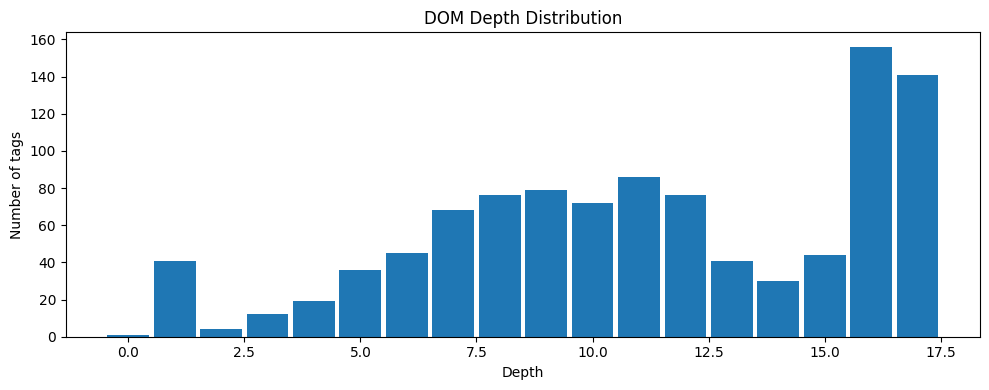

In [40]:
plt.figure(figsize=(10, 4))
plt.hist(depths, bins=range(0, max(depths) + 2), align="left", rwidth=0.9)
plt.title("DOM Depth Distribution")
plt.xlabel("Depth")
plt.ylabel("Number of tags")
plt.tight_layout()
plt.show()


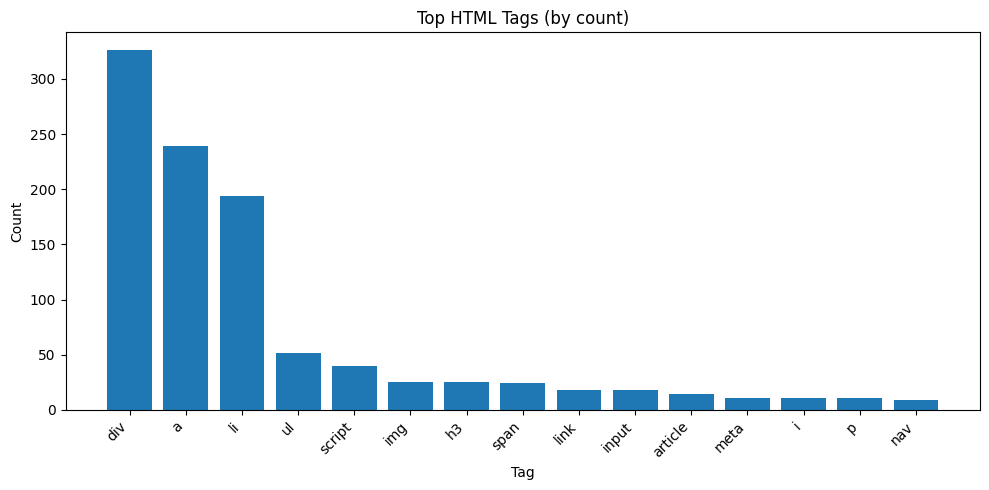

In [36]:
#Top HTML Tags（棒グラフ）

from collections import Counter
import matplotlib.pyplot as plt
from bs4 import Tag

tags = [t.name.lower().split(":")[-1] for t in soup.find_all(True)]
counts = Counter(tags)
top = counts.most_common(15)

labels, values = zip(*top)

plt.figure(figsize=(10, 5))
plt.bar(labels, values)
plt.title("Top HTML Tags (by count)")
plt.xlabel("Tag")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [37]:
#4236

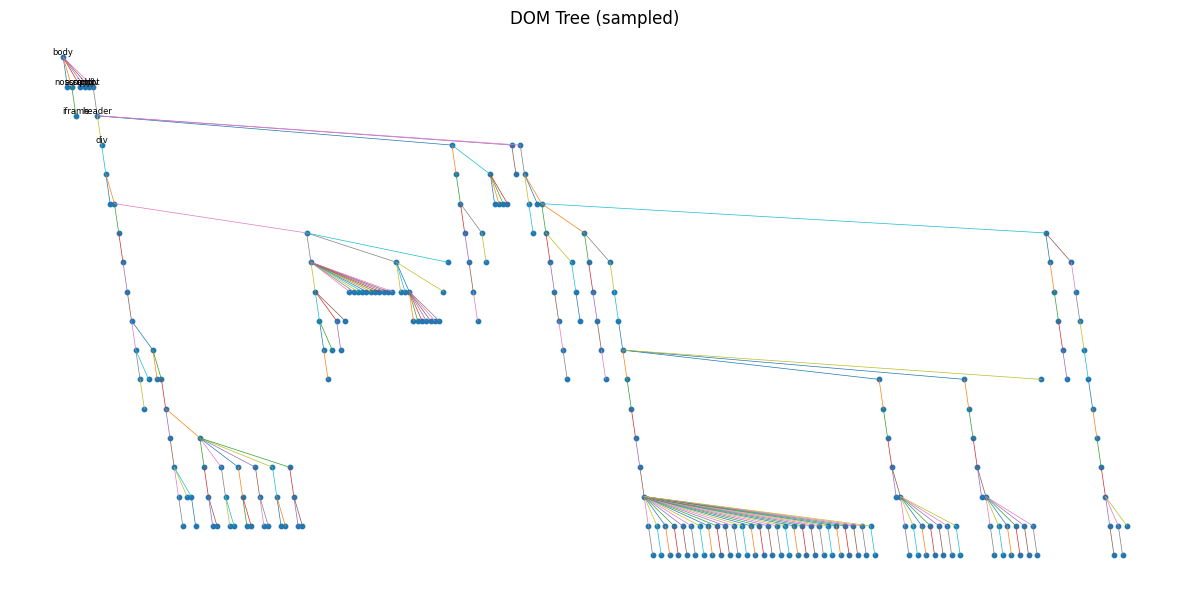

In [38]:
#DOM Tree 可視化
import matplotlib.pyplot as plt
from bs4 import Tag

def dom_subtree(root, max_nodes=300):
    nodes = []
    edges = []
    stack = [(root, 0, None)]

    while stack and len(nodes) < max_nodes:
        node, depth, parent = stack.pop()
        if not isinstance(node, Tag):
            continue

        idx = len(nodes)
        nodes.append({
            "idx": idx,
            "name": node.name,
            "depth": depth,
            "parent": parent
        })

        if parent is not None:
            edges.append((parent, idx))

        children = [c for c in node.children if isinstance(c, Tag)]
        for ch in reversed(children):
            stack.append((ch, depth + 1, idx))

    return nodes, edges

root = soup.body or soup
nodes, edges = dom_subtree(root, max_nodes=250)

x = list(range(len(nodes)))
y = [-n["depth"] for n in nodes]

plt.figure(figsize=(12, 6))

for u, v in edges:
    plt.plot([x[u], x[v]], [y[u], y[v]], linewidth=0.5)

plt.scatter(x, y, s=10)

for n in nodes[:40]:
    if n["depth"] <= 3:
        plt.text(x[n["idx"]], y[n["idx"]], n["name"],
                 fontsize=6, ha="center", va="bottom")

plt.title("DOM Tree (sampled)")
plt.axis("off")
plt.tight_layout()
plt.show()


In [39]:
#メタ情報・OG・Twitter
#Can you guess...videoのラストパート
from urllib.parse import urljoin

title = (soup.title.string or "").strip() if soup.title else ""

meta = {
    (m.get("name") or m.get("property", "")).lower(): m.get("content", "")
    for m in soup.find_all("meta") if m.get("content")
}

canonical = soup.find("link", rel=lambda v: v and "canonical" in v.lower())
canonical = canonical.get("href") if canonical else ""

og = {m["property"]: m["content"]
      for m in soup.select('meta[property^="og:"]')}

tw = {m["name"]: m["content"]
      for m in soup.select('meta[name^="twitter:"]')}

print(
    title,
    meta.get("description", ""),
    meta.get("robots", ""),
    canonical,
    len(og),
    len(tw)
)


World Health Organization (WHO) The United Nations agency working to promote health, keep the world safe and serve the vulnerable.  https://www.who.int 4 1
